# 差分进化算法（DE）

差分进化（Differential Evolution, DE）是一种**面向连续优化问题**的群体智能启发式算法。

它和遗传算法一样，也会维护一组候选解，但它的“进化”方式并不是传统意义上的“父母交叉生孩子”，而是直接利用**个体之间的差值**来构造新的搜索方向。

简单说，DE 的核心不是选谁当爹妈或是怎么拼接基因，而是：

- 看看当前解和其他解之间“差了多少”
- 用这种“差值信息”去推动新解产生
- 再用贪心方式决定新解能不能留下

它特别适合以下场景：

- 连续变量优化问题
- 非线性、非凸、多峰函数优化
- 难以直接求导的问题
- 数学建模中的参数估计、函数拟合、连续选址、控制参数寻优等问题



# 问题定义

对于一个连续优化问题：

$$
\min_{x \in \Omega} f(x)
$$

其中：

- $x = (x_1, x_2, \dots, x_D)^T$ 是待优化变量；
- $D$ 是决策变量维数；
- $f(x)$ 是目标函数；
- $\Omega$ 是可行域，通常可写成变量边界约束：

$$
\Omega = \{x \in \mathbb{R}^D \mid L_j \le x_j \le U_j,\; j = 1,2,\dots,D\}
$$

如果是最大化问题，也可以转化为最小化问题，例如：

$$
\max f(x) \quad \Longleftrightarrow \quad \min (-f(x))
$$

差分进化算法首先生成一个大小为 $NP$ 的种群：

$$
P^{(0)} = \{x_1^{(0)}, x_2^{(0)}, \dots, x_{NP}^{(0)}\}
$$

其中每个个体 $x_i^{(0)} \in \mathbb{R}^D$，也就是一个 $D$ 维实数向量。



# 核心机制

差分进化的核心思想可以概括成一句话：

> **用“解与解之间的差”来构造搜索步长，再用竞争机制保留更好的解。**

一个标准的 DE 算法通常包含三个关键步骤：

1. **变异（Mutation）**：利用种群中不同个体的差值，生成“变异向量”；
2. **交叉（Crossover）**：把原个体和变异向量混合，生成“试验向量”；
3. **选择（Selection）**：比较新旧个体谁更优，优者进入下一代。

注意，DE 虽然也有“变异、交叉、选择”这几个词，但和遗传算法里的含义并不完全一样。

---

# 1. 编码（Encoding）

DE 几乎天然适用于**实数编码**。

如果要求解一个 $D$ 维连续变量问题，那么一个个体通常直接写成：

$$
x_i = (x_{i1}, x_{i2}, \dots, x_{iD})
$$

例如当我们要优化二维变量 $(x, y)$ 时，一个个体就可以表示为：

```text
[2.31, -1.47]
```

这意味着 DE 不需要像二进制遗传算法那样先做“编码—解码”转换，表示方式更直接。

---

# 2. 变异（Mutation）

变异是 DE 最关键的一步。

以最经典的 **DE/rand/1** 为例：对第 $i$ 个目标个体 $x_i^{(g)}$，从种群中随机选出三个互不相同且与 $i$ 不同的个体：

$$
x_{r1}^{(g)},\; x_{r2}^{(g)},\; x_{r3}^{(g)}
$$

构造变异向量：

$$
v_i^{(g)} = x_{r1}^{(g)} + F\big(x_{r2}^{(g)} - x_{r3}^{(g)}\big)
$$

其中：

- $v_i^{(g)}$ 是变异向量；
- $F$ 是缩放因子（Differential Weight），通常取 $(0,2)$ 内的数；
- $x_{r2}^{(g)} - x_{r3}^{(g)}$ 反映了两个个体之间的差异方向和差异幅度。

这一步最妙的地方在于：

> **DE 不是凭空乱跳，而是借助当前种群内部的“差异”来决定怎么跳。**

如果种群分布很分散，步长就会比较大；如果种群逐渐收缩，步长也会自然变小。

---

# 3. 交叉（Crossover）

有了变异向量 $v_i^{(g)}$ 之后，DE 不会直接拿它替换原个体，而是会进一步和目标个体 $x_i^{(g)}$ 做交叉，产生试验向量 $u_i^{(g)}$。

最常见的是二项交叉（binomial crossover）：

$$
u_{ij}^{(g)} =
\begin{cases}
v_{ij}^{(g)}, & \text{if } rand_j \le CR \text{ or } j = j_{\text{rand}} \\
x_{ij}^{(g)}, & \text{otherwise}
\end{cases}
$$

其中：

- $CR \in [0,1]$ 是交叉概率；
- $j_{\text{rand}}$ 是随机指定的一个维度，保证试验向量至少有一维来自变异向量；
- $u_i^{(g)}$ 是生成的新候选解。

直观理解就是：

- 以较大概率从变异向量里拿分量；
- 以较小概率保留原个体的分量；
- 从而在“保留旧信息”和“引入新方向”之间折中。

---

# 4. 选择（Selection）

DE 的选择非常直接，通常采用**一对一贪心选择**：

对于目标个体 $x_i^{(g)}$ 和对应试验向量 $u_i^{(g)}$，比较它们的目标函数值。

若是最小化问题，则：

$$
x_i^{(g+1)} =
\begin{cases}
u_i^{(g)}, & \text{if } f(u_i^{(g)}) \le f(x_i^{(g)}) \\
x_i^{(g)}, & \text{otherwise}
\end{cases}
$$

也就是说：

- 新解更好，就替换旧解；
- 新解不如旧解，旧解继续保留。

这使得 DE 的种群质量通常不会明显倒退，收敛行为比较稳定。

---

# 人话

如果把遗传算法理解成“让一群候选方案不断繁殖和筛选”，

那么差分进化更像是：

> **看几份还不错的方案之间到底差在哪里，再顺着这个差异方向去试一个新方案。**

比如现在有三个方案：

- 方案 A：成本低，但速度一般
- 方案 B：速度快，但风险偏高
- 方案 C：成本和速度都比较折中

DE 会做的事情不是简单拼接 A 和 B，而是：

- 先看 B 和 C 差了多少
- 把这种“差值”作为一种方向
- 再把这个方向加到 A 上
- 生成一个新的候选方案

所以它的直觉是：

> **不是“谁和谁生孩子”，而是“谁和谁差多少，我就朝这个差值方向走一步看看”。**

这也是差分进化名字里“差分”两个字的来源。

---

# 基本流程

一个标准的 DE/rand/1/bin 流程如下。

## 初始化

在每个维度的上下界内随机生成种群：

$$
x_{ij}^{(0)} = L_j + rand_{ij}(U_j - L_j)
$$

其中：

- $i = 1,2,\dots,NP$
- $j = 1,2,\dots,D$

## 对每一代重复以下步骤

### 第一步：变异

对每个目标个体 $x_i^{(g)}$，随机选取 $r1,r2,r3$，构造：

$$
v_i^{(g)} = x_{r1}^{(g)} + F\big(x_{r2}^{(g)} - x_{r3}^{(g)}\big)
$$

### 第二步：交叉

由目标个体 $x_i^{(g)}$ 和变异向量 $v_i^{(g)}$ 产生试验向量 $u_i^{(g)}$。

### 第三步：边界处理

若 $u_i^{(g)}$ 某一维超出边界，则可采用以下方式处理：

- 截断到边界
- 随机重置
- 反射回可行域

### 第四步：选择

比较 $u_i^{(g)}$ 与 $x_i^{(g)}$ 的优劣，保留更优者进入下一代。

### 第五步：判断是否终止

若满足以下任一条件，则停止：

- 达到最大迭代次数；
- 目标函数值达到预期；
- 连续若干代提升很小。



# 一个极简例子：求多峰函数最小值

假设我们要最小化下面这个二维函数：

$$
f(x,y) = x^2 + y^2 - 10\big(\cos(2\pi x)+\cos(2\pi y)\big) + 20
$$

定义域为：

$$
x,y \in [-5.12, 5.12]
$$

这就是经典的 **Rastrigin 函数**。它的特点是：

- 全局最优点明确；
- 局部极小值很多；
- 很适合测试群体智能算法的全局搜索能力。

我们可以这样理解 DE 的求解过程：

- 每个个体是一个二维向量 $[x,y]$；
- 初始随机生成很多个点；
- 利用个体之间的差值方向构造变异向量；
- 通过交叉产生新点；
- 哪个点函数值更小，哪个就留下。

最终，种群会逐渐向全局最优区域靠近。

---

# 一个最小可运行示例

下面给出一个极简版差分进化示例，用来最小化二维 Rastrigin 函数。





In [1]:
import random
import math

# 目标函数：Rastrigin
def f(x):
    return 10 * len(x) + sum(v * v - 10 * math.cos(2 * math.pi * v) for v in x)

# 边界处理
def clip(vec, lower, upper):
    return [max(lower[i], min(upper[i], vec[i])) for i in range(len(vec))]

# 差分进化主程序
def de(dim=2, pop_size=30, generations=200, F=0.7, CR=0.9,
       lower=None, upper=None, seed=42):
    random.seed(seed)
    if lower is None:
        lower = [-5.12] * dim
    if upper is None:
        upper = [5.12] * dim

    # 初始化种群
    pop = [
        [random.uniform(lower[j], upper[j]) for j in range(dim)]
        for _ in range(pop_size)
    ]

    best = min(pop, key=f)
    best_val = f(best)

    for _ in range(generations):
        new_pop = []

        for i in range(pop_size):
            # 选取三个互不相同的随机个体
            ids = list(range(pop_size))
            ids.remove(i)
            r1, r2, r3 = random.sample(ids, 3)

            x1, x2, x3 = pop[r1], pop[r2], pop[r3]

            # 变异
            v = [x1[j] + F * (x2[j] - x3[j]) for j in range(dim)]
            v = clip(v, lower, upper)

            # 交叉
            u = pop[i][:]
            j_rand = random.randrange(dim)
            for j in range(dim):
                if random.random() < CR or j == j_rand:
                    u[j] = v[j]

            # 选择
            if f(u) <= f(pop[i]):
                new_pop.append(u)
            else:
                new_pop.append(pop[i])

        pop = new_pop

        current_best = min(pop, key=f)
        current_best_val = f(current_best)
        if current_best_val < best_val:
            best = current_best[:]
            best_val = current_best_val

    return best, best_val

best_x, best_y = de()
print("best_x =", best_x)
print("best_f =", best_y)

best_x = [8.265078113434702e-10, 1.6772994561407434e-09]
best_f = 0.0



这个版本虽然很简化，但已经包含了 DE 最核心的三件事：

- 差分变异
- 交叉生成试验向量
- 贪心选择

---

# 为什么差分进化有效

差分进化之所以常常有效，关键在于它把“探索”和“利用”结合得比较自然。

## 1. 探索（Exploration）

变异向量来自：

$$
x_{r2} - x_{r3}
$$

这相当于从当前种群里自动提取一个“搜索方向”。

由于种群初期分布较散，这个差值通常较大，算法探索能力较强。

## 2. 利用（Exploitation）

试验向量最终要和当前个体一对一竞争。

只有更好的解才能存活下来，这就让算法不断强化已经发现的优质区域。

## 3. 自适应步长的味道

DE 的步长不是固定常数，而是和种群分布状态有关。

种群差异大时，搜索步长往往较大；
种群逐渐收缩时，搜索步长也会相应缩小。

这让 DE 具有一种很实用的特性：

> **前期敢跑，后期敢收。**

---

# 差分进化的几个关键参数

DE 的参数通常没有遗传算法那么多，但每个都很关键。

## 1. 种群规模（Population Size, $NP$）

- 太小：多样性不足，容易早熟
- 太大：函数评估开销变高

经验上，$NP$ 常常设置为维数 $D$ 的若干倍，例如 `5D ~ 10D`。

## 2. 缩放因子（$F$）

- 控制差分向量的放大程度
- $F$ 太小：步子太短，搜索保守
- $F$ 太大：步子太猛，容易震荡

常见经验取值约为 `0.4 ~ 0.9`。

## 3. 交叉概率（$CR$）

- 控制试验向量有多少维来自变异向量
- $CR$ 高：更大胆地接受新结构
- $CR$ 低：更多保留原个体

常见经验取值约为 `0.1 ~ 0.9`。

## 4. 迭代次数（Generations）

迭代次数越多，通常搜索越充分，但计算成本也更高。

---

# 常见变体

差分进化常用“DE/基向量/差分数/交叉方式”来命名。

例如：

## 1. DE/rand/1/bin

$$
v_i = x_{r1} + F(x_{r2} - x_{r3})
$$

- 最经典
- 全局探索能力较强
- 稳定、通用

## 2. DE/best/1/bin

$$
v_i = x_{best} + F(x_{r1} - x_{r2})
$$

- 以当前最优个体为基点
- 收敛更快
- 但更容易早熟

## 3. DE/current-to-best/1

$$
v_i = x_i + F(x_{best} - x_i) + F(x_{r1} - x_{r2})
$$

- 同时利用当前个体、最优个体和差分信息
- 开发能力更强
- 对参数更敏感

---

# 约束处理怎么做

数学建模中的问题，很少只有简单边界约束，更多时候还会出现：

- 等式约束
- 不等式约束
- 资源约束
- 逻辑约束

DE 处理约束时，常见做法有：

## 1. 罚函数法

把违反约束的程度写进目标函数：

$$
F_{\text{obj}}(x) = f(x) + \lambda \cdot \text{Penalty}(x)
$$

优点是实现简单，建模时很常用。

## 2. 修复法（Repair）

如果新解不可行，就把它修正回可行域。

例如：

- 超出边界就截断
- 不满足总量约束就重新归一化
- 不满足排序约束就做局部修复

## 3. 可行性优先规则

比较两个解时：

- 可行解优于不可行解；
- 若都可行，比目标值；
- 若都不可行，比违反约束程度。

这种规则在竞赛论文里也很常见。

---

# 一个建模视角的例子：非线性参数估计

差分进化在数学建模里一个非常常见的用法，是做**参数估计**。

假设我们有一组观测数据 $(t_i, y_i)$，希望拟合下面这个非线性模型：

$$
y(t) = a e^{-bt} + c
$$

这里参数 $a,b,c$ 未知。

我们可以把问题写成最小二乘优化：

$$
\min_{a,b,c} \sum_{i=1}^{n}\left(y_i - (a e^{-b t_i} + c)\right)^2
$$

这时候：

- 决策变量：$x = (a,b,c)$
- 目标函数：残差平方和
- 可行域：参数上下界
- 算法：DE

这类问题的好处是：

- 参数是连续变量；
- 目标函数可能非凸；
- 不一定容易手推梯度；
- DE 可以直接黑盒优化。

---

# 建模例题：连续平面双站点选址优化

这个例子比单纯的函数极值更接近数学建模中的“应用题”。

## 问题背景

某地区要建设 **2 个应急物资中转站**，服务 10 个需求点。每个需求点有：

- 平面坐标 $(x_i, y_i)$
- 权重 $w_i$（代表需求量或重要程度）

要求确定两个站点的位置：

$$
(x_1, y_1),\; (x_2, y_2)
$$

使得每个需求点都由离它更近的站点服务，并让加权总服务距离最小。

## 数学模型

设第 $k$ 个站点坐标为 $(X_k, Y_k)$，则目标函数可写成：

$$
\min \sum_{i=1}^{n} w_i \cdot \min_{k \in \{1,2\}}
\sqrt{(x_i - X_k)^2 + (y_i - Y_k)^2}
$$

若再考虑“站点不能建在禁建区”“两个站点之间不能太近”等要求，还可以加入罚函数项。

这类问题的特点是：

- 决策变量是连续的；
- 目标函数不可导也没关系；
- 局部最优较多；
- 很适合用 DE 直接搜索。



最优站点坐标： [59.99999990377447, 22.00000009924052, 22.537941021864974, 25.823411693622575]
最优目标值： 928.7708773794993


c:\Users\48137\anaconda3\envs\DeepLearning\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 36845 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\48137\anaconda3\envs\DeepLearning\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 20195 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\48137\anaconda3\envs\DeepLearning\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 25968 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\48137\anaconda3\envs\DeepLearning\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 24403 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\48137\anaconda3\envs\DeepLearning\lib\site-packages\matplotlib\backends\backend_agg.py:240: RuntimeWarning: Glyph 21069 missing from current font.
  font.set_text(s, 0.0, flags=flags)
c:\Users\48137\anaconda3\envs\DeepL

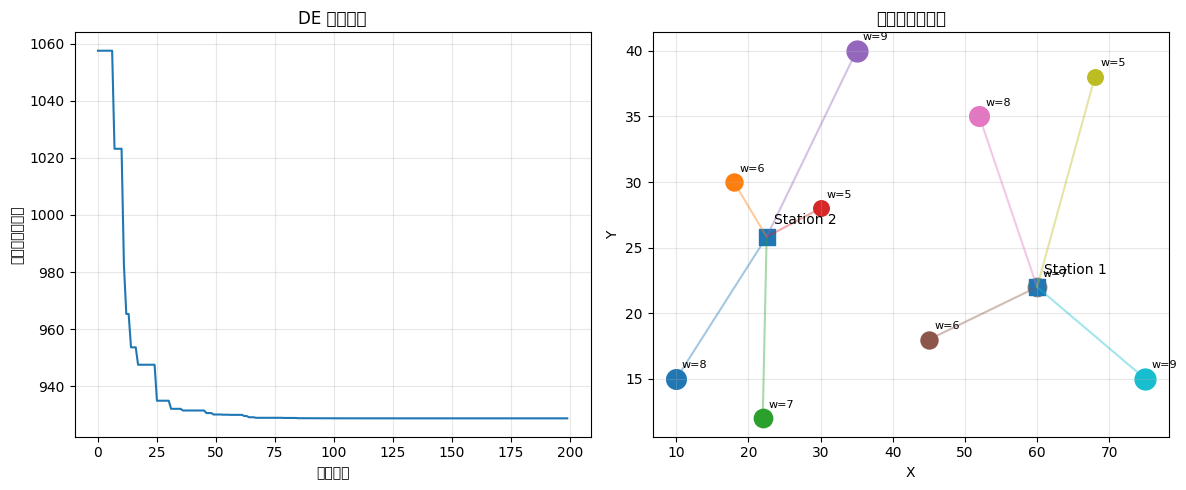

In [2]:
import random
import math
import matplotlib.pyplot as plt

# 需求点：x, y, weight
points = [
    (10, 15, 8),
    (18, 30, 6),
    (22, 12, 7),
    (30, 28, 5),
    (35, 40, 9),
    (45, 18, 6),
    (52, 35, 8),
    (60, 22, 7),
    (68, 38, 5),
    (75, 15, 9),
]

# 目标函数：两个站点坐标分别为 (x1,y1),(x2,y2)
def objective(vec):
    x1, y1, x2, y2 = vec
    total = 0.0

    # 两站点过近时加罚
    dist_12 = math.hypot(x1 - x2, y1 - y2)
    penalty = 0.0
    if dist_12 < 12:
        penalty += 1000 * (12 - dist_12)

    for px, py, w in points:
        d1 = math.hypot(px - x1, py - y1)
        d2 = math.hypot(px - x2, py - y2)
        total += w * min(d1, d2)

    return total + penalty

def clip(vec, lower, upper):
    return [max(lower[i], min(upper[i], vec[i])) for i in range(len(vec))]

def differential_evolution(dim, pop_size, generations, F, CR, lower, upper, seed=42):
    random.seed(seed)

    pop = [
        [random.uniform(lower[j], upper[j]) for j in range(dim)]
        for _ in range(pop_size)
    ]

    best = min(pop, key=objective)
    best_val = objective(best)
    history = []

    for _ in range(generations):
        new_pop = []
        for i in range(pop_size):
            ids = list(range(pop_size))
            ids.remove(i)
            r1, r2, r3 = random.sample(ids, 3)

            x1, x2, x3 = pop[r1], pop[r2], pop[r3]
            v = [x1[j] + F * (x2[j] - x3[j]) for j in range(dim)]
            v = clip(v, lower, upper)

            u = pop[i][:]
            j_rand = random.randrange(dim)
            for j in range(dim):
                if random.random() < CR or j == j_rand:
                    u[j] = v[j]

            if objective(u) <= objective(pop[i]):
                new_pop.append(u)
            else:
                new_pop.append(pop[i])

        pop = new_pop
        cur_best = min(pop, key=objective)
        cur_best_val = objective(cur_best)

        if cur_best_val < best_val:
            best = cur_best[:]
            best_val = cur_best_val

        history.append(best_val)

    return best, best_val, history

def plot_result(best, history):
    x1, y1, x2, y2 = best

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history)
    plt.xlabel("迭代代数")
    plt.ylabel("当前最优目标值")
    plt.title("DE 收敛过程")
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    for px, py, w in points:
        plt.scatter(px, py, s=25 * w)
        plt.text(px + 0.8, py + 0.8, f"w={w}", fontsize=8)

    plt.scatter([x1, x2], [y1, y2], marker="s", s=120)
    plt.text(x1 + 1, y1 + 1, "Station 1")
    plt.text(x2 + 1, y2 + 1, "Station 2")

    for px, py, _ in points:
        d1 = math.hypot(px - x1, py - y1)
        d2 = math.hypot(px - x2, py - y2)
        if d1 <= d2:
            plt.plot([px, x1], [py, y1], alpha=0.4)
        else:
            plt.plot([px, x2], [py, y2], alpha=0.4)

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("双站点选址结果")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    lower = [0, 0, 0, 0]
    upper = [80, 50, 80, 50]

    best, best_val, history = differential_evolution(
        dim=4,
        pop_size=40,
        generations=200,
        F=0.7,
        CR=0.9,
        lower=lower,
        upper=upper,
        seed=42
    )

    print("最优站点坐标：", best)
    print("最优目标值：", best_val)
    plot_result(best, history)

## Python 代码

```python

```

## 这个例题的价值

这个例子适合放进数学建模文档，是因为它能体现 DE 的几个典型特点：

- 变量是连续坐标，天然适合 DE；
- 目标函数里可以直接写距离、权重和罚函数；
- 不需要梯度，也不需要解析解；
- 可以很方便扩展到多站点、多约束、多目标场景。

---

# 与遗传算法的直观比较

如果把遗传算法和差分进化放在一起看，可以粗略这样理解：

## 遗传算法更像

- 维护一群候选解
- 通过选择、交叉、变异进化
- 编码方式更灵活
- 对排列组合类问题很常见

## 差分进化更像

- 维护一群实数向量
- 通过“向量差分”生成新解
- 对连续优化尤其顺手
- 实现往往更简单、参数更少

所以很多时候可以这样记：

> **排列组合问题，先想到遗传算法；连续参数优化问题，先想到差分进化。**

当然，这不是绝对规则，但作为入门判断很有用。

---

# 常见优点与局限

## 优点

- 实数优化问题中实现简单
- 不要求目标函数可导
- 全局搜索能力较强
- 参数量相对不多
- 很适合做黑盒优化和参数寻优

## 局限

- 不能保证一定找到全局最优
- 高维复杂问题下函数评估成本可能较高
- 参数 $F$、$CR$、$NP$ 仍然会影响效果
- 在强约束、离散变量问题上通常不如专门设计的编码方法自然

所以在工程和建模里，DE 常常不是“万能钥匙”，但它是：

> **连续优化场景里，一把非常顺手、非常耐用的启发式工具。**

---

# 适合继续扩展的内容

这一版先把 DE 的主线搭起来。后续可以继续补充：

1. DE/rand/1/bin、DE/best/1/bin 的性能比较  
2. 自适应差分进化（jDE、JADE、SHADE）  
3. 差分进化处理约束优化的几种策略  
4. 差分进化与粒子群、模拟退火的比较  
5. 差分进化求解参数估计问题的完整案例  
6. 差分进化与局部搜索混合形成混合启发式算法  

---

# 一句话总结

差分进化的本质是：

> **让候选解彼此“做差”，再顺着这个差值方向试探新解，并在竞争中把更优解留下来。**

如果你是第一次接触它，只要先记住这三个词就够了：

**差分变异、交叉、贪心选择。**

这三步，就是差分进化的骨架。